# Zero-Shot Evaluation — READ `checkpoint-8368` on the Bullinger (ENHG) test set

This notebook evaluates the READ/Bozen fine-tuned TrOCR checkpoint (`checkpoint-8368`) on a
dataset it has **never seen** — the [Bullinger HTR dataset](https://github.com/pstroe/bullinger-htr):
16th-century correspondence of Heinrich Bullinger (1504-1575). No fine-tuning happens here.

**Why this dataset:** same era/script family as Bozen (16th-c. German cursive), the lines are
already cropped (`.png` + `.txt` pairs — no PAGE-XML step), and it has a defined test split, so it
gives a clean, informative *in-domain generalization* number.

**Important:** Bullinger is multilingual (Latin `la/` + Early New High German `de/`). The model is
German-adapted, so we evaluate **only the `de/` (ENHG) subset** — Latin would inflate CER unfairly.

**Run on a Colab GPU runtime** (Runtime → Change runtime type → GPU). The first test archive is
~1.85 GB and holds 694 German lines, which is plenty for a zero-shot estimate; add more archives in
the config cell for a larger sample.

In [8]:
# Colab usually has torch + transformers; evaluate/jiwer are needed for CER/WER.
!pip -q install evaluate jiwer

In [9]:
import os
import zipfile
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import evaluate

from glob import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, default_data_collator

plt.rcParams["figure.figsize"] = (12, 4)

# Mount Drive
The checkpoint lives on Drive (same location the fine-tune notebook saved it to).

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE_TYPE = device.type
print(f"Using device: {device}  (type: {DEVICE_TYPE})")
if DEVICE_TYPE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected — generation will be slow; select a GPU runtime.")

Using device: cuda  (type: cuda)
GPU: NVIDIA L4


# Config

In [ ]:
# --- Model: the READ fine-tune checkpoint to evaluate (on Drive) ---
CHECKPOINT_DIR = "/content/drive/MyDrive/READ/models/read_trocr_checkpoint/checkpoint-8368"
BASE_MODEL     = "microsoft/trocr-base-handwritten"  # processor (preprocessor+tokenizer) source

# --- Generation / batching ---
MAX_TARGET_LENGTH = 128
BATCH_SIZE        = 8
NUM_BEAMS         = 4

# --- Bullinger test data (Git-LFS zip archives, served via the GitHub media endpoint) ---
# Ranges are by document ID. Each archive is ~1.85 GB and unzips to <range>/de and <range>/la.
# de-line counts per archive: 0-2000:694  2001-4000:265  4001-6000:188  6001-8000:246
#                             8001-10000:392  10001-12000:741  12001-14000:551   (3077 total)
BULLINGER_MEDIA = "https://media.githubusercontent.com/media/pstroe/bullinger-htr/main/test"
ARCHIVES = ["0-2000-out.zip"]   # add more for a larger sample, e.g. "10001-12000-out.zip"

DL_DIR        = "/content/bullinger_dl"      # downloaded zips (local, ephemeral)
EXTRACT_DIR   = "/content/bullinger_test"    # extracted de/ line crops (local, ephemeral)
MAX_EVAL_LINES = None   # cap number of lines for a quick run; None = use all German lines found

print("Checkpoint:", CHECKPOINT_DIR)
print("Archives  :", ARCHIVES)

Checkpoint: /content/drive/MyDrive/READ/models/read_trocr_checkpoint/checkpoint-8368
Archives  : ['0-2000-out.zip', '2001-4000-out.zip', '4001-6000-out.zip', '6001-8000-out.zip', '8001-10000-out.zip', '10001-12000-out.zip', '12001-14000-out.zip']


# Download & Extract the Bullinger test archive(s)
Only the German (`de/`) members are extracted. Downloads use `wget -c`, so a re-run resumes
rather than re-downloading.

In [7]:
os.makedirs(DL_DIR, exist_ok=True)
os.makedirs(EXTRACT_DIR, exist_ok=True)

for a in ARCHIVES:
    dest = os.path.join(DL_DIR, a)
    url  = f"{BULLINGER_MEDIA}/{a}"
    print(f"Downloading {a} ...")
    !wget -c -q --show-progress -O "{dest}" "{url}"
    print(f"  {a}: {os.path.getsize(dest)/1e9:.2f} GB")

    # Extract only the German (de/) line crops + transcriptions
    with zipfile.ZipFile(dest) as zf:
        de_members = [m for m in zf.namelist() if "/de/" in m]
        zf.extractall(EXTRACT_DIR, members=de_members)
    print(f"  extracted {len(de_members)} de/ members")

/content/bullinger_ 100%[===================>]   1.73G  16.9MB/s    in 1m 41s  
  0-2000-out.zip: 1.86 GB
  extracted 1389 de/ members


In [ ]:
# Build the eval dataframe from the (de/) .png + .txt pairs
png_files = sorted(glob(os.path.join(EXTRACT_DIR, "**", "de", "*.png"), recursive=True))

rows = []
for p in png_files:
    txt = p[:-4] + ".txt"
    if not os.path.exists(txt):
        continue
    with open(txt, encoding="utf-8") as f:
        text = f.read().strip()
    if text:
        rows.append({"file_name": p, "text": text})

test_df = pd.DataFrame(rows).reset_index(drop=True)
if MAX_EVAL_LINES:
    test_df = test_df.sample(min(MAX_EVAL_LINES, len(test_df)), random_state=42).reset_index(drop=True)

print(f"German (ENHG) test lines: {len(test_df)}")
test_df.head()

German (ENHG) test lines: 694


,file_name,text
0,/content/bullinger_test/0-2000-out/de/1019_00_...,Es were sein fürnemen im Obern Teutschland
1,/content/bullinger_test/0-2000-out/de/1027_01_...,Basel.
2,/content/bullinger_test/0-2000-out/de/1030_01_...,in dem truk außgon laßen; wirt bald harkhommen...
3,/content/bullinger_test/0-2000-out/de/1030_01_...,Frieß ist eylendtz verritten; ist nie zuͦ mir ...
4,/content/bullinger_test/0-2000-out/de/1030_01_...,"muͤssend all anhalten, damit wir in der eydgno..."


/tmp/ipykernel_75285/3693024247.py:10: UserWarning: Glyph 870 (\N{COMBINING LATIN SMALL LETTER O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_75285/3693024247.py:10: UserWarning: Glyph 868 (\N{COMBINING LATIN SMALL LETTER E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 870 (\N{COMBINING LATIN SMALL LETTER O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 868 (\N{COMBINING LATIN SMALL LETTER E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


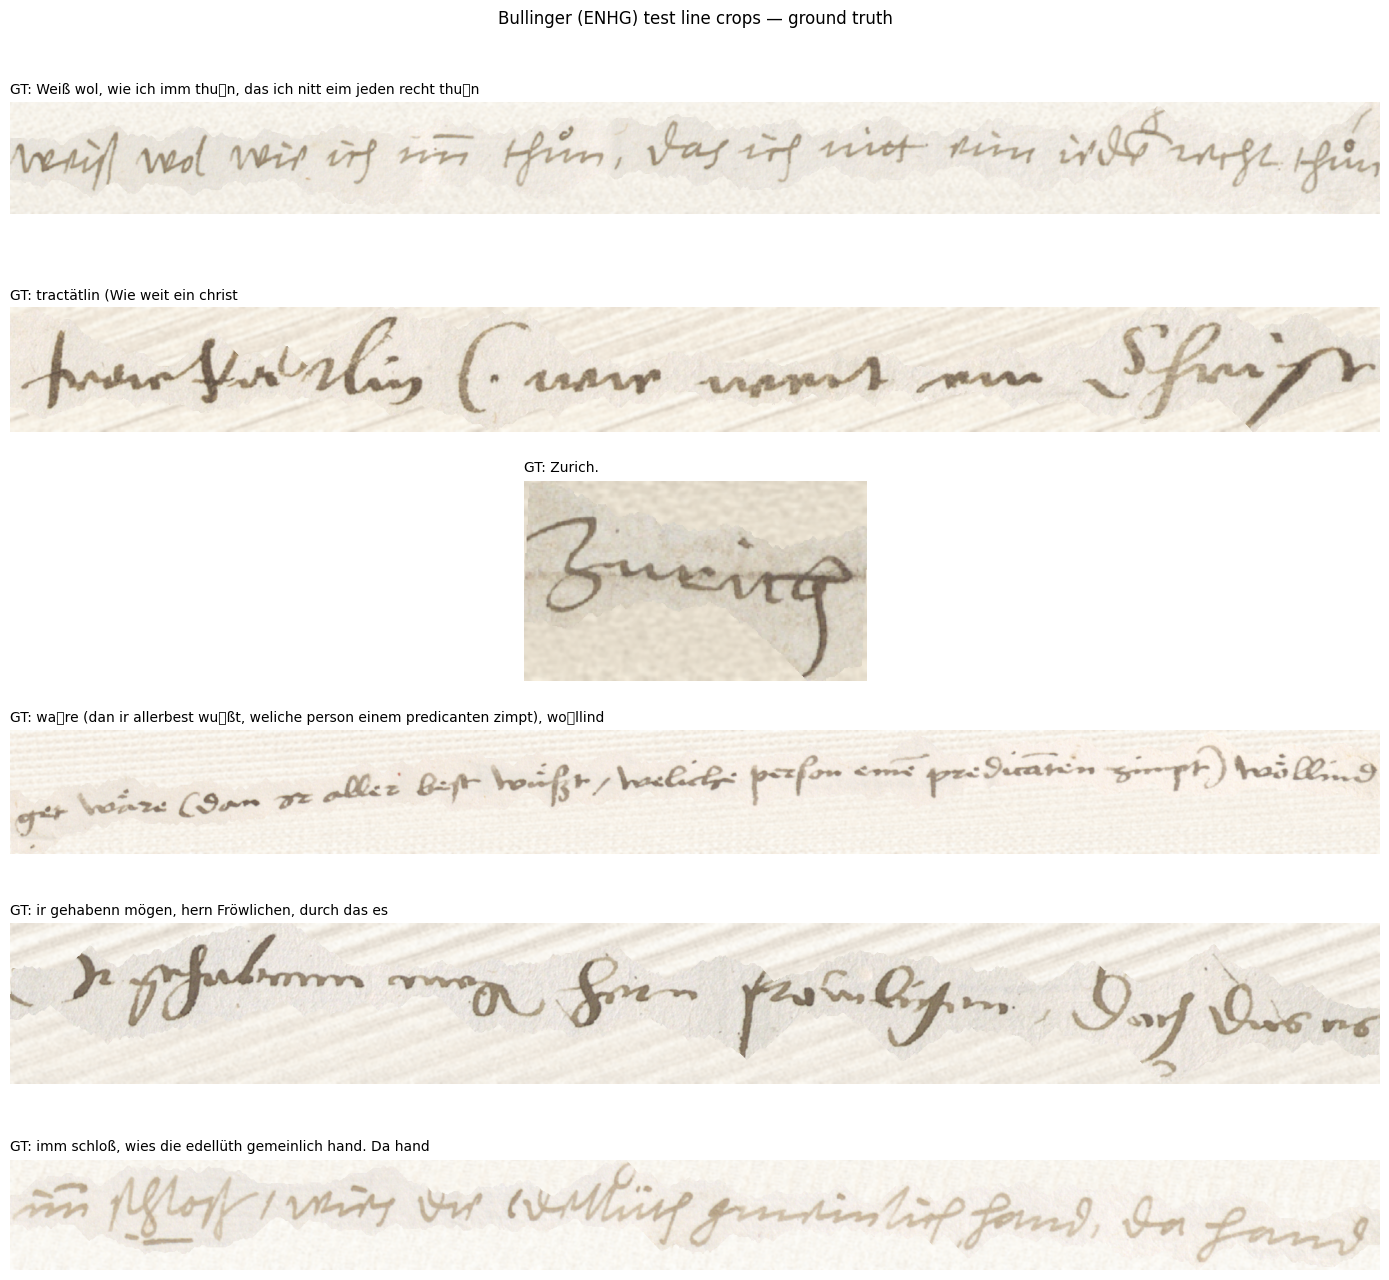

In [ ]:
# Peek at a few line crops with their ground-truth transcriptions
N_SHOW = 6
sample = test_df.sample(min(N_SHOW, len(test_df)), random_state=0).reset_index(drop=True)
fig, axes = plt.subplots(len(sample), 1, figsize=(14, 2.2 * len(sample)))
for ax, row in zip(axes, sample.itertuples()):
    ax.imshow(Image.open(row.file_name), cmap="gray")
    ax.set_title(f"GT: {row.text}", fontsize=10, loc="left")
    ax.axis("off")
plt.suptitle("Bullinger (ENHG) test line crops — ground truth", y=1.0)
plt.tight_layout()
plt.show()

# Dataset, Model & Metrics

In [ ]:
# Same preprocessing as the fine-tune notebook's eval path: grayscale -> 3 channels, no augmentation.
class LineOCRDataset(Dataset):
    def __init__(self, df, processor, transforms=None, max_target_length=128):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.transforms = transforms
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = Image.open(self.df["file_name"][idx]).convert("RGB")
        if self.transforms:
            image = self.transforms(image)
        pixel_values = self.processor(image, return_tensors="pt").pixel_values
        labels = self.processor.tokenizer(
            self.df["text"][idx],
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
        ).input_ids
        labels = [l if l != self.processor.tokenizer.pad_token_id else -100 for l in labels]
        return {"pixel_values": pixel_values.squeeze(), "labels": torch.tensor(labels)}

eval_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
])

In [ ]:
# A Trainer checkpoint stores only model weights — load the processor from the base model
# (unchanged by fine-tuning) and the model from the checkpoint.
processor  = TrOCRProcessor.from_pretrained(BASE_MODEL)
eval_model = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT_DIR)

eval_model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
eval_model.config.pad_token_id           = processor.tokenizer.pad_token_id
eval_model.config.eos_token_id           = processor.tokenizer.sep_token_id
eval_model.config.vocab_size             = eval_model.config.decoder.vocab_size
eval_model.generation_config.max_length  = MAX_TARGET_LENGTH
eval_model.generation_config.num_beams   = NUM_BEAMS

eval_model.to(device)
eval_model.eval()

test_dataset = LineOCRDataset(test_df, processor, eval_transforms, MAX_TARGET_LENGTH)
print("Model loaded from", CHECKPOINT_DIR)
print("Test lines:", len(test_dataset))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Model loaded from /content/drive/MyDrive/READ/models/read_trocr_checkpoint/checkpoint-8368
Test lines: 694


In [ ]:
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

# Zero-Shot Evaluation — CER / WER

In [ ]:
eval_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=default_data_collator)

eval_model.eval()
all_preds, all_refs = [], []
with torch.no_grad():
    for batch in eval_loader:
        pixel_values = batch["pixel_values"].to(device)
        generated_ids = eval_model.generate(
            pixel_values, max_length=MAX_TARGET_LENGTH, num_beams=NUM_BEAMS,
        )
        preds = processor.batch_decode(generated_ids, skip_special_tokens=True)
        labels = batch["labels"].clone()
        labels[labels == -100] = processor.tokenizer.pad_token_id
        refs = processor.batch_decode(labels, skip_special_tokens=True)
        all_preds.extend(preds)
        all_refs.extend(refs)

final_cer = cer_metric.compute(predictions=all_preds, references=all_refs)
final_wer = wer_metric.compute(predictions=all_preds, references=all_refs)
print(f"Zero-shot on Bullinger (ENHG) — {len(all_refs)} lines")
print(f"  CER: {final_cer:.4f}")
print(f"  WER: {final_wer:.4f}")

print("\nSample predictions:")
for pred, ref in list(zip(all_preds, all_refs))[:10]:
    print(f"  GT  : {ref}")
    print(f"  PRED: {pred}\n")

Zero-shot on Bullinger (ENHG) — 694 lines
  CER: 0.6719
  WER: 1.1208

Sample predictions:
  GT  : Es were sein fürnemen im Obern Teutschland
  PRED: leg Er vor vor vor v̈rerren vor obren vnd

  GT  : Basel.
  PRED: Basil

  GT  : in dem truk außgon laßen; wirt bald harkhommen. M. Hans
  PRED: enden vnd aūf Zarten werderten Haimen. M. Lamp¬

  GT  : Frieß ist eylendtz verritten; ist nie zuͦ mir khomen. Hat mich ettwas
  PRED: Zū Occist: seiner sein Zū no khain. Zū noch etc

  GT  : muͤssend all anhalten, damit wir in der eydgnoschaft gantz
  PRED: missen Morgen, dem vor miten Erger Pfert genz¬

  GT  : zum großen Münster.
  PRED: Zūm groß: vnd Maūsiz

  GT  : Zurich.
  PRED: Amn:

  GT  : und mag vor ingendem februario, so der clöstren
  PRED: vnd neg vnd vnd vnd vnd vnd vnd vnd Ir Gn:

  GT  : dem willen sins vatters säligen gern nachkommen sin; dann
  PRED: den wider wo vorcoschigen gar nehtenen sichtenen dem

  GT  : inen min tochter lassen bevolhen sin. Tuam humanitatem
  PRED: von

# Visualise sample predictions with scores

/tmp/ipykernel_75285/1875159870.py:31: UserWarning: Glyph 870 (\N{COMBINING LATIN SMALL LETTER O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


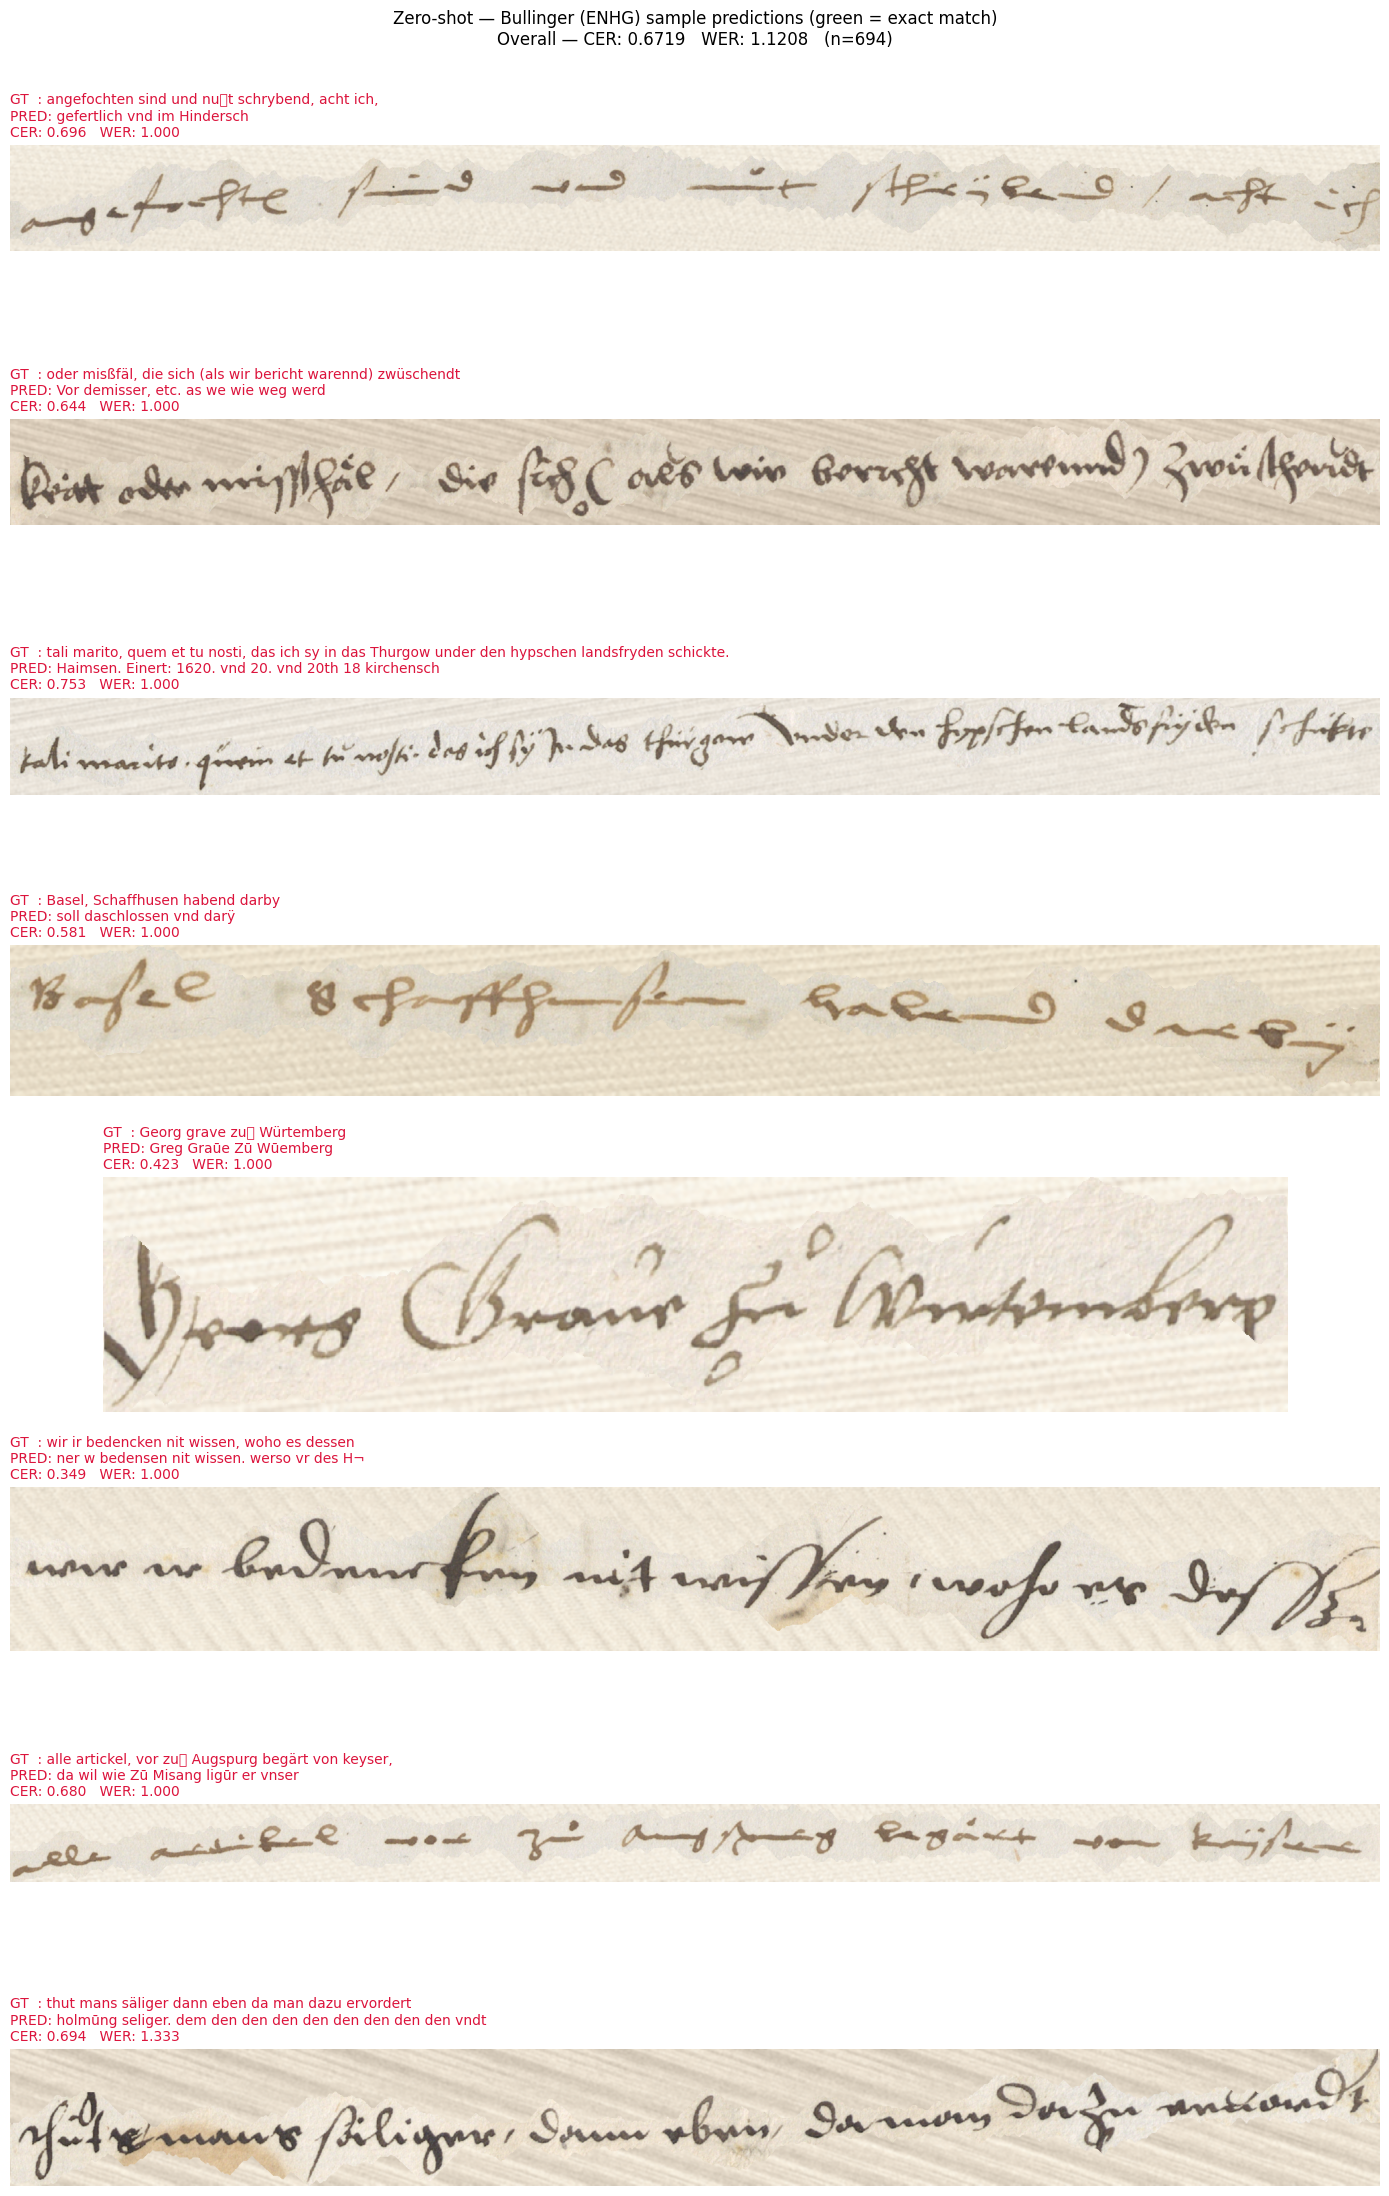

In [ ]:
N_SHOW = 8
sample = test_df.sample(min(N_SHOW, len(test_df)), random_state=42).reset_index(drop=True)

eval_model.eval()
fig, axes = plt.subplots(len(sample), 1, figsize=(14, 2.8 * len(sample)))
if len(sample) == 1:
    axes = [axes]

with torch.no_grad():
    for ax, row in zip(axes, sample.itertuples()):
        image = Image.open(row.file_name).convert("RGB")
        proc_image = eval_transforms(image)
        pixel_values = processor(proc_image, return_tensors="pt").pixel_values.to(device)
        generated_ids = eval_model.generate(
            pixel_values, max_length=MAX_TARGET_LENGTH, num_beams=NUM_BEAMS,
        )
        pred = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        line_cer = cer_metric.compute(predictions=[pred], references=[row.text])
        line_wer = wer_metric.compute(predictions=[pred], references=[row.text])
        match = pred.strip() == row.text.strip()
        ax.imshow(image, cmap="gray")
        ax.set_title(f"GT  : {row.text}\nPRED: {pred}\nCER: {line_cer:.3f}   WER: {line_wer:.3f}",
                     fontsize=10, loc="left", color="green" if match else "crimson")
        ax.axis("off")

plt.suptitle(
    f"Zero-shot — Bullinger (ENHG) sample predictions (green = exact match)\n"
    f"Overall — CER: {final_cer:.4f}   WER: {final_wer:.4f}   (n={len(all_refs)})",
    y=1.0,
)
plt.tight_layout()
plt.show()

# 10 worst predictions by CER

10 worst lines by CER:
  CER 5.878  WER 9.000
    GT  : habend 3 artikel fürtragen: 1. Damitt dem
    PRED: vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd

  CER 5.540  WER 8.000
    GT  : sind, mine bschwerden zuͦ erwegen; deßhalb mir die
    PRED: ner sind win vnd vnd vnd vnd wernd vnd vnd vnd vnd vnd vnd vnd vnd vnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imnd imie im imie imnd imnd imnd im imnd

  CER 5.130  WER 8.000
    GT  : sy, die v Ort, veraͤter geschulten, die gaͤllt
    PRED: (: 8 k. 8 k. vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd 7nd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd vnd

/tmp/ipykernel_75285/466628379.py:29: UserWarning: Glyph 870 (\N{COMBINING LATIN SMALL LETTER O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_75285/466628379.py:29: UserWarning: Glyph 868 (\N{COMBINING LATIN SMALL LETTER E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


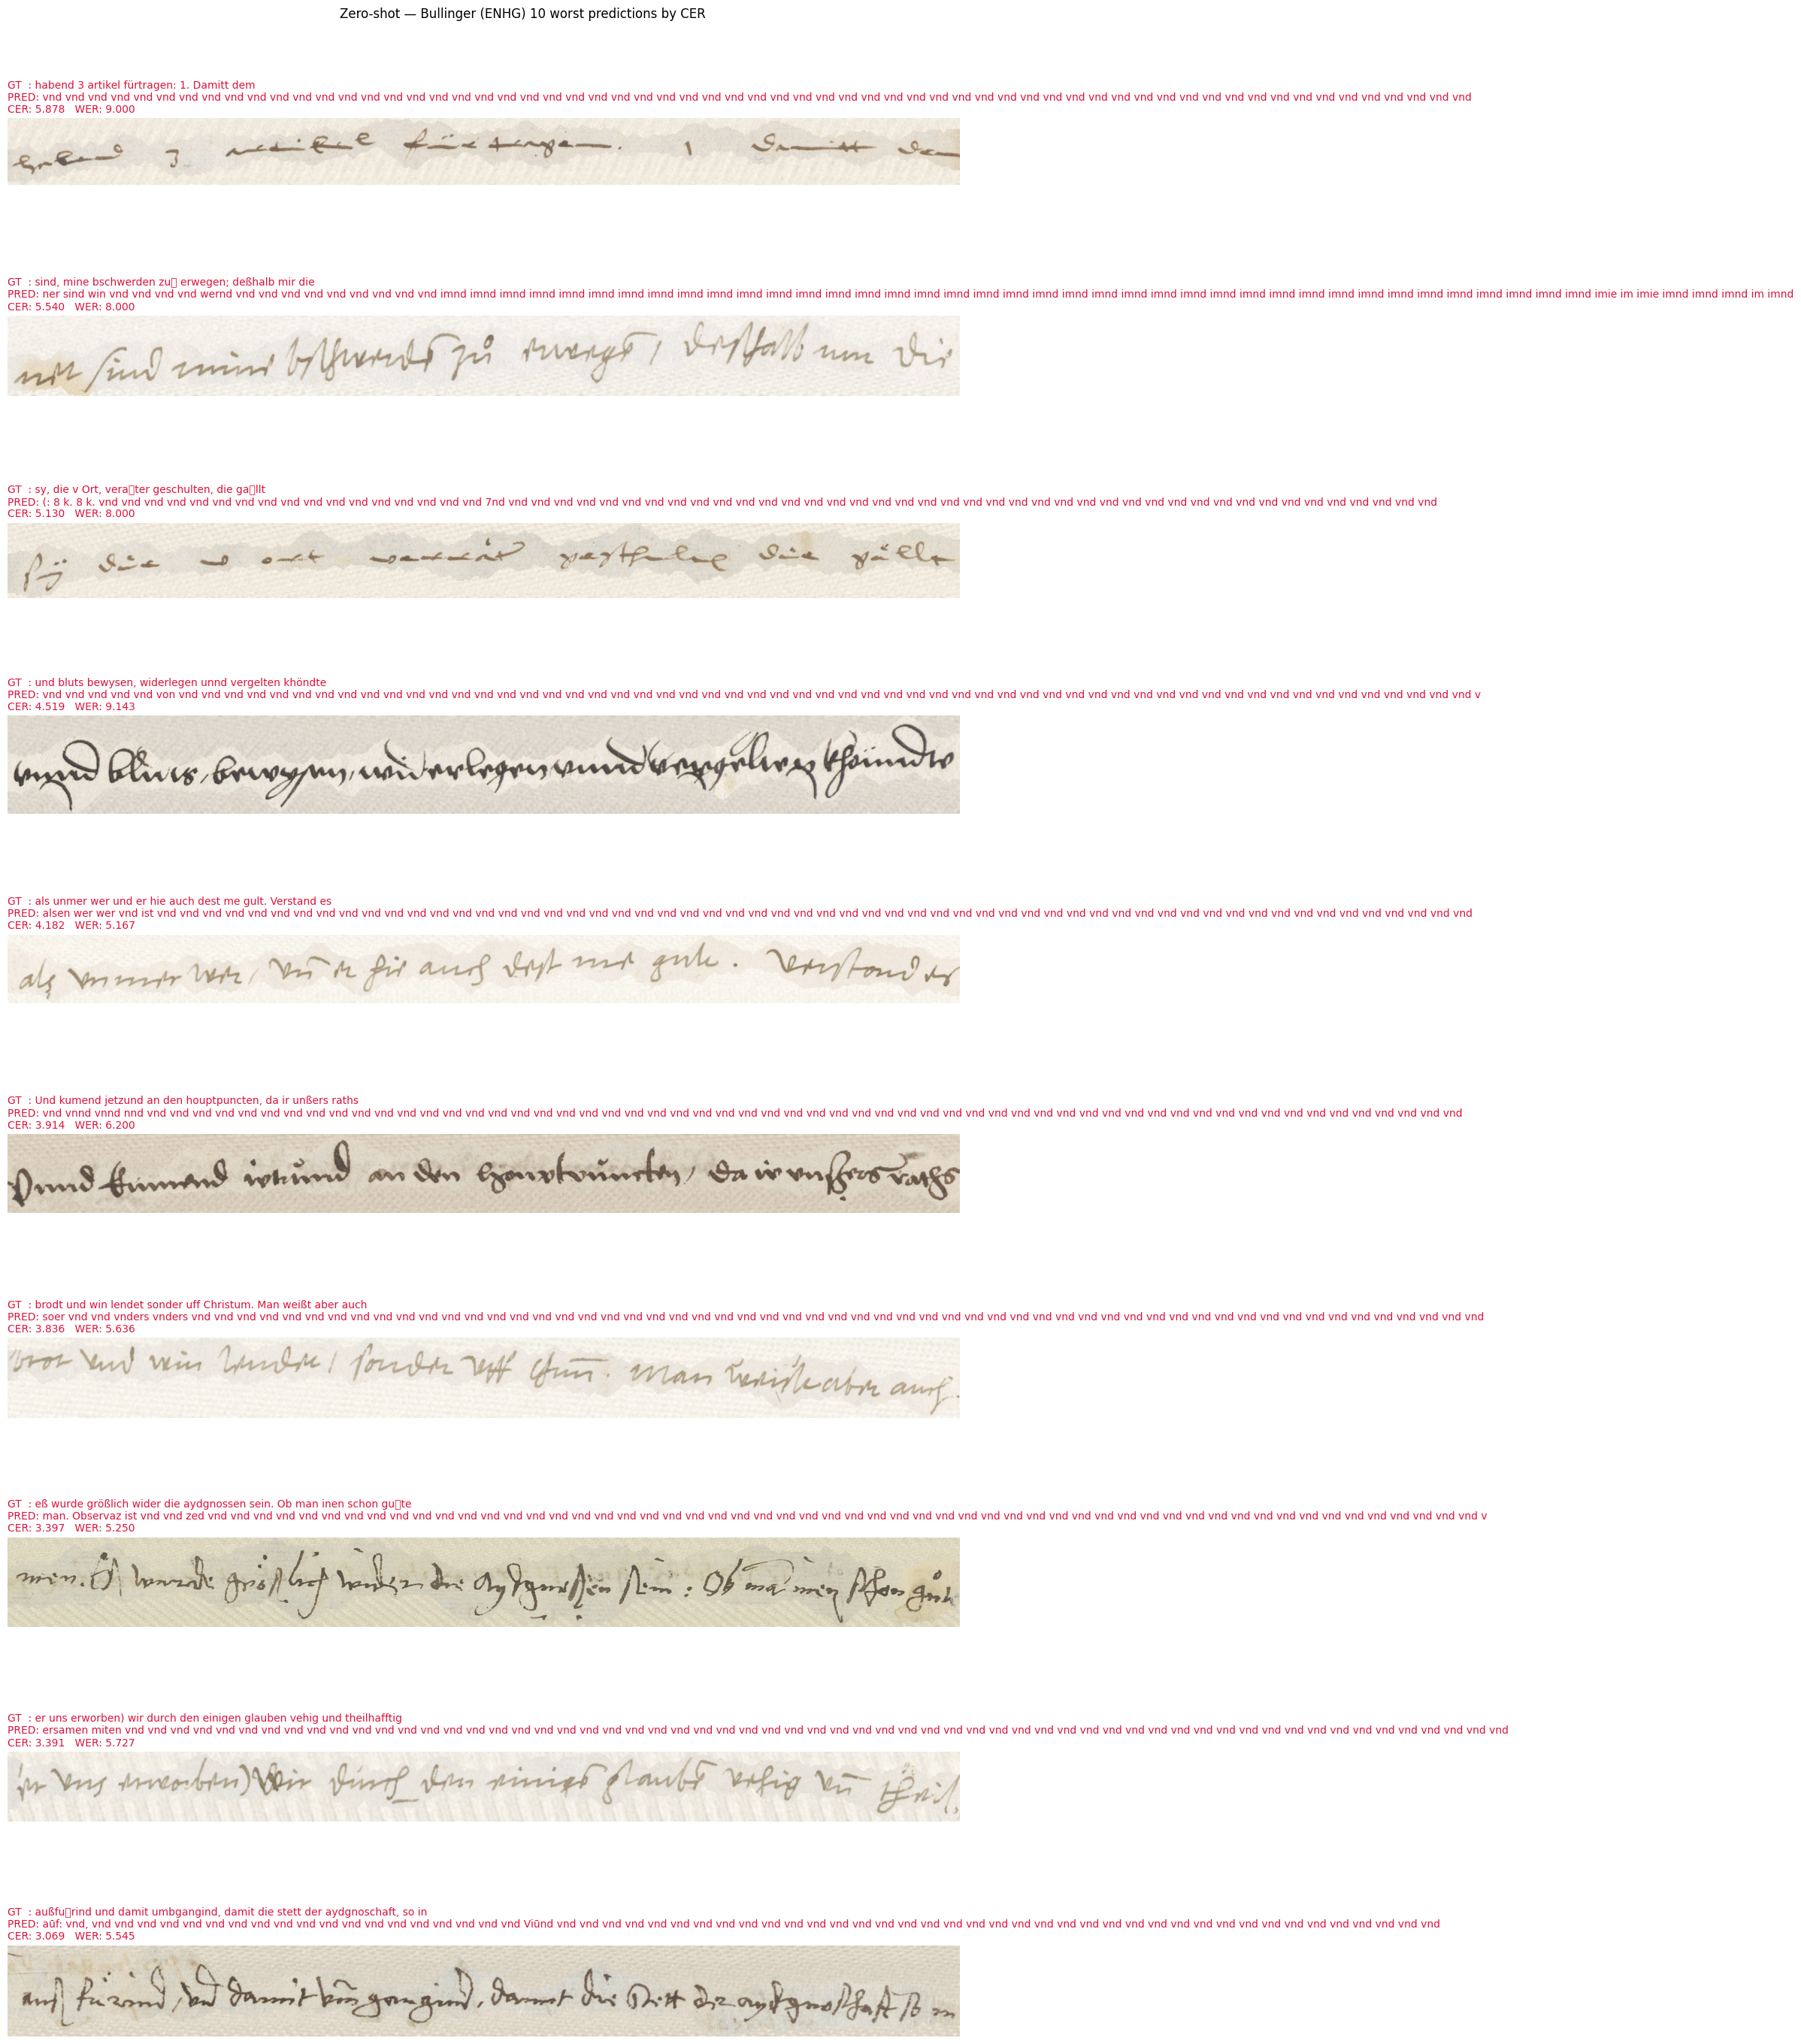

In [ ]:
# all_preds / all_refs are aligned with test_df row order (DataLoader used shuffle=False).
assert len(all_preds) == len(test_df), "Re-run the eval cell so all_preds aligns with test_df"

per_line = []
for i, (pred, ref) in enumerate(zip(all_preds, all_refs)):
    c = cer_metric.compute(predictions=[pred], references=[ref])
    w = wer_metric.compute(predictions=[pred], references=[ref])
    per_line.append({"idx": i, "cer": c, "wer": w,
                     "file_name": test_df["file_name"].iloc[i],
                     "gt": ref, "pred": pred})

worst = sorted(per_line, key=lambda r: (r["cer"], r["wer"]), reverse=True)[:10]

print("10 worst lines by CER:")
for r in worst:
    print(f"  CER {r['cer']:.3f}  WER {r['wer']:.3f}")
    print(f"    GT  : {r['gt']}")
    print(f"    PRED: {r['pred']}\n")

fig, axes = plt.subplots(len(worst), 1, figsize=(14, 2.8 * len(worst)))
if len(worst) == 1:
    axes = [axes]
for ax, r in zip(axes, worst):
    ax.imshow(Image.open(r["file_name"]).convert("RGB"), cmap="gray")
    ax.set_title(f"GT  : {r['gt']}\nPRED: {r['pred']}\nCER: {r['cer']:.3f}   WER: {r['wer']:.3f}",
                 fontsize=10, loc="left", color="crimson")
    ax.axis("off")
plt.suptitle("Zero-shot — Bullinger (ENHG) 10 worst predictions by CER", y=1.0)
plt.tight_layout()
plt.show()